
# Plot Opinions & Delegations (**Optimal**, **Probabilistic**, **Frozen**)

This notebook plots delegators and DReps on the \([0,1]\) opinion line for a chosen epoch, with edges to their assigned DRep.
It supports three data sources:

- **optimal** — closest-by-opinion each epoch (`csv_out_optimal/`)
- **probabilistic** — stickiness + utility switching (`csv_out_probabilistic/`)
- **frozen** — delegation fixed from first-seen epoch (`csv_out_frozen/`)

You can plot a single epoch or export **all epochs** for any source (and even for **all sources**).


In [62]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random as _r

# ---------------- Parameters ----------------
SOURCE = "optimal"   # "optimal", "probabilistic", or "frozen"
EPOCH  = None        # set to an int to force a specific epoch; None -> first available

# Visual params
USE_STAKE_SIZE     = True
SIZE_SCALE_DELEG   = 15.0
SIZE_SCALE_DREPS   = 0.5
JITTER             = 0.015
DRAW_EDGES         = True
EDGE_SAMPLES       = 2000     # None for all edges; int to subsample
EDGE_ALPHA         = 0.30
EDGE_LW            = 0.7
COLOR_SWITCHED     = True     # only used when SOURCE="probabilistic"

# ---------------- Load data ----------------
if SOURCE == "optimal":
    BASE = Path("csv_out_optimal")
    DELEG_PATH = BASE / "delegators_state_with_delegations.csv"
    DREPS_PATH = BASE / "dreps_state_with_wprime.csv"
    deleg_df = pd.read_csv(DELEG_PATH)
    dreps_df = pd.read_csv(DREPS_PATH)
    print("Loaded optimal delegation CSVs.")
elif SOURCE == "probabilistic":
    BASE = Path("csv_out_probabilistic")
    DELEG_PATH = BASE / "delegations_probabilistic.csv"
    DREPS_PATH = BASE / "dreps_wprime_probabilistic.csv"
    deleg_df = pd.read_csv(DELEG_PATH)
    dreps_df = pd.read_csv(DREPS_PATH)
    print("Loaded probabilistic CSVs.")
elif SOURCE == "frozen":
    BASE = Path("csv_out_frozen")
    DELEG_PATH = BASE / "delegators_state_frozen.csv"
    DREPS_PATH = BASE / "dreps_state_with_wprime_frozen.csv"
    deleg_df = pd.read_csv(DELEG_PATH)
    dreps_df = pd.read_csv(DREPS_PATH)
    print("Loaded frozen delegation CSVs.")
else:
    raise ValueError("SOURCE must be 'optimal', 'probabilistic', or 'frozen'")

print("Deleg path:", DELEG_PATH.resolve())
print("DReps path:", DREPS_PATH.resolve())

epochs = sorted(set(deleg_df['epoch']).intersection(set(dreps_df['epoch'])))
print("Epochs available:", (epochs[:10] if len(epochs)>10 else epochs), "... total:", len(epochs))
if EPOCH is None:
    EPOCH = int(epochs[0])
print("Selected epoch:", EPOCH)


Loaded optimal delegation CSVs.
Deleg path: /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out_optimal/delegators_state_with_delegations.csv
DReps path: /Users/Joel/Documents/GitHub/ada_drep/simulation/csv_out_optimal/dreps_state_with_wprime.csv
Epochs available: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... total: 10
Selected epoch: 0


In [63]:

def ensure_probabilistic_columns(A: pd.DataFrame) -> pd.DataFrame:
    """Ensure probabilistic delegations have opinion/stake/s (merge from minimal CSVs if needed)."""
    if ('opinion' not in A.columns) or ('stake' not in A.columns) or ('s' not in A.columns) or ('drep_opinion' not in A.columns):
        base_deleg = pd.read_csv(Path("csv_out") / "delegators_state.csv")  # epoch, delegator_id, opinion, stake, s
        base_dreps = pd.read_csv(Path("csv_out") / "dreps_state.csv")       # epoch, drep_id, opinion, stake
        A = A.merge(base_deleg[['epoch','delegator_id','opinion','stake','s']], on=['epoch','delegator_id'], how='left')
        A = A.merge(base_dreps[['epoch','drep_id','opinion']].rename(columns={'opinion':'drep_opinion'}),
                    on=['epoch','drep_id'], how='left')
    if 'switched' not in A.columns:
        A['switched'] = 0
    return A

def plot_epoch_from_csv_unified(
    epoch: int,
    deleg_df: pd.DataFrame,
    dreps_df: pd.DataFrame,
    source: str = "optimal",
    use_stake_size: bool = True,
    size_scale_deleg: float = 20.0,
    size_scale_dreps: float = 20.0,
    jitter: float = 0.02,
    draw_edges: bool = True,
    edge_alpha: float = 0.25,
    edge_lw: float = 0.6,
    edge_samples: int | None = None,
    edge_random_seed: int | None = 123,
    color_switched: bool = True,
):
    D = dreps_df[dreps_df['epoch'] == epoch].copy()
    A = deleg_df[deleg_df['epoch'] == epoch].copy()
    if D.empty or A.empty:
        raise ValueError(f"No data at epoch {epoch}")

    # Harmonize columns by source
    if source == "probabilistic":
        A = ensure_probabilistic_columns(A)
    else:
        if 'switched' not in A.columns:
            A['switched'] = 0  # not used but keeps API consistent

    # X positions
    x_deleg = A['opinion'].astype(float).to_list()
    x_dreps = D['opinion'].astype(float).to_list()

    # Y rows + jitter
    y_row_deleg = 0.35
    y_row_dreps = 0.65
    y_deleg = [y_row_deleg + (_r.uniform(-jitter, jitter) if jitter > 0 else 0.0) for _ in x_deleg]
    y_dreps = [y_row_dreps + (_r.uniform(-jitter, jitter) if jitter > 0 else 0.0) for _ in x_dreps]

    # Sizes
    if use_stake_size:
        s_deleg = [max(10.0, float(s) * size_scale_deleg) for s in A['stake']]
        size_source = D['Wprime'] if 'Wprime' in D.columns else D['stake']
        s_dreps = [max(10.0, float(s) * size_scale_dreps) for s in size_source]
    else:
        s_deleg = [25.0] * len(x_deleg)
        s_dreps = [40.0] * len(x_dreps)

    # DRep positions for edges
    drep_pos = {d: (x, y) for d, x, y in zip(D['drep_id'].astype(str), x_dreps, y_dreps)}

    # Plot
    fig, ax = plt.subplots(figsize=(10, 3.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0.2, 0.8)
    ax.hlines(0.5, 0.0, 1.0, linestyles="dashed", linewidth=0.8)

    # Edges
    if draw_edges:
        idxs = list(A.index)
        if edge_samples is not None and edge_samples < len(idxs):
            _rng = _r.Random(edge_random_seed)
            idxs = _rng.sample(idxs, edge_samples)

        pos_map = {idx: pos for pos, idx in enumerate(A.index)}
        for i in idxs:
            a = A.loc[i]
            x1 = float(a['opinion'])
            y1 = y_deleg[pos_map[i]]
            drid = str(a['drep_id'])
            x2, y2 = drep_pos.get(drid, (None, None))
            if x2 is None:
                continue

            if (source in ["probabilistic","optimal"]) and color_switched:
                col = "C3" if int(a['switched']) == 1 else "0.4"
                alp = 0.55 if int(a['switched']) == 1 else edge_alpha
            else:
                col = "0.35"; alp = edge_alpha

            ax.plot([x1, x2], [y1, y2], linewidth=edge_lw, alpha=alp, color=col)

    # Scatter points
    ax.scatter(x_deleg, y_deleg, s=s_deleg, alpha=0.6, marker="o", label="Delegators")
    ax.scatter(x_dreps, y_dreps, s=s_dreps, alpha=0.9, marker="s", label="DReps")

    # Labels
    ax.set_xlabel("Opinion in [0, 1]")
    ax.set_yticks([y_row_deleg, 0.5, y_row_dreps], labels=["Delegators", "", "DReps"])
    ax.set_title(f"Opinions & delegations (epoch {epoch}, {source})")
    ax.legend(loc="upper center", ncol=2, frameon=False)
    fig.tight_layout()
    return fig, ax


In [64]:

OUT_DIR = Path("plots_from_csv") / SOURCE
OUT_DIR.mkdir(parents=True, exist_ok=True)

for e in epochs:
    fig, ax = plot_epoch_from_csv_unified(
        int(e), deleg_df, dreps_df, source=SOURCE,
        use_stake_size=USE_STAKE_SIZE, size_scale_deleg=SIZE_SCALE_DELEG, size_scale_dreps=SIZE_SCALE_DREPS,
        jitter=JITTER, draw_edges=DRAW_EDGES, edge_alpha=EDGE_ALPHA, edge_lw=EDGE_LW,
        edge_samples=EDGE_SAMPLES, color_switched=COLOR_SWITCHED
    )
    fig.savefig(OUT_DIR / f"epoch_{int(e):04d}.png", dpi=160, bbox_inches="tight")
    plt.close(fig)

print(f"Saved {len(epochs)} images to {OUT_DIR.resolve()}")


Saved 10 images to /Users/Joel/Documents/GitHub/ada_drep/simulation/plots_from_csv/optimal


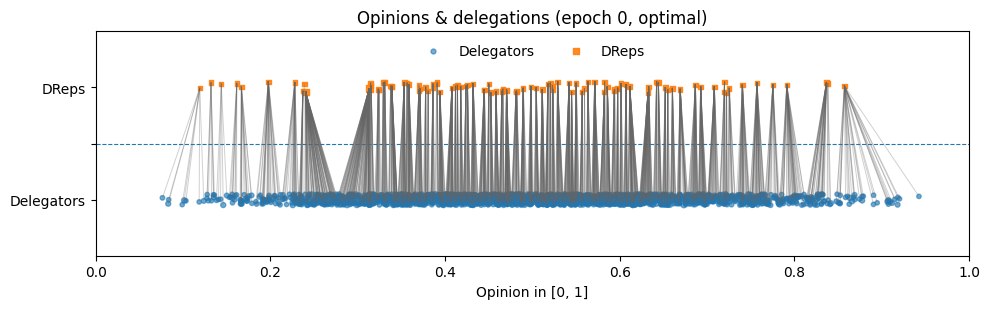

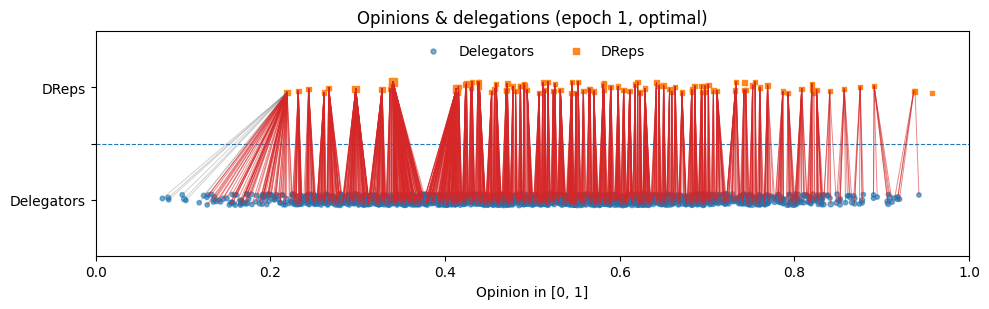

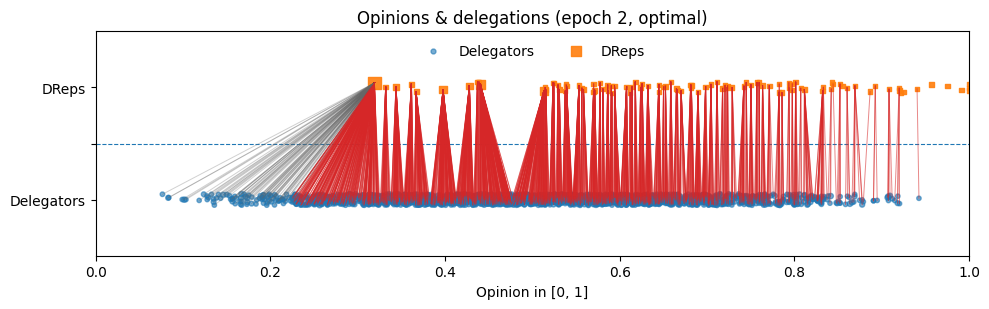

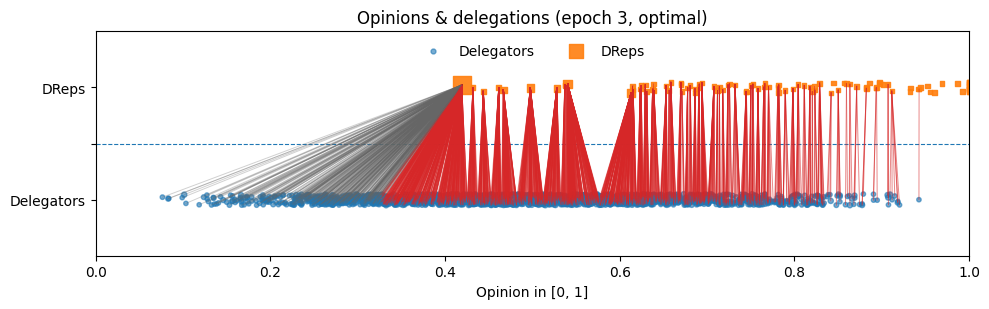

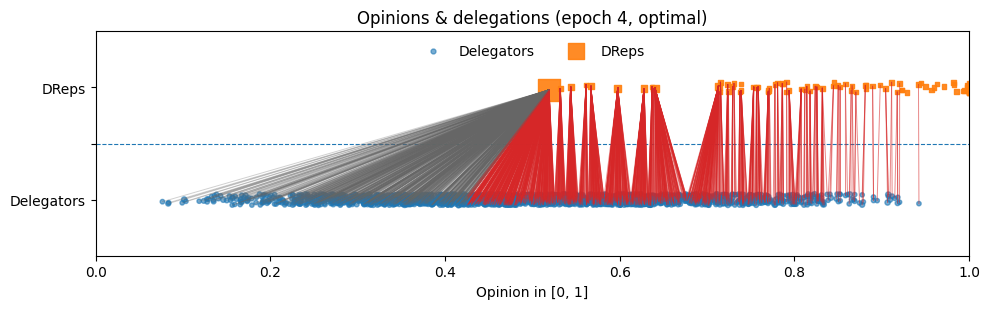

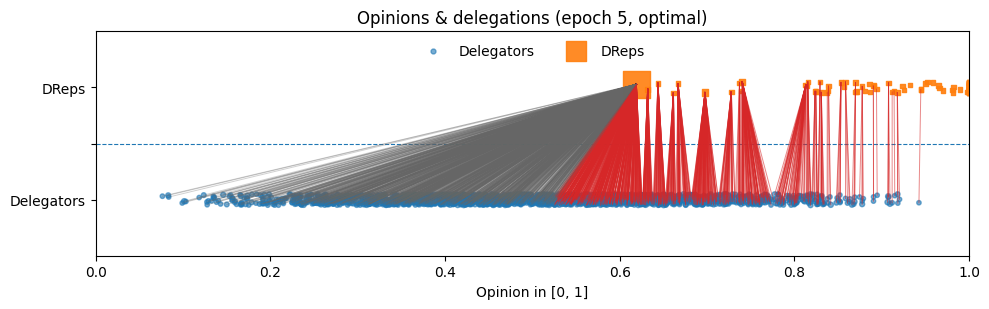

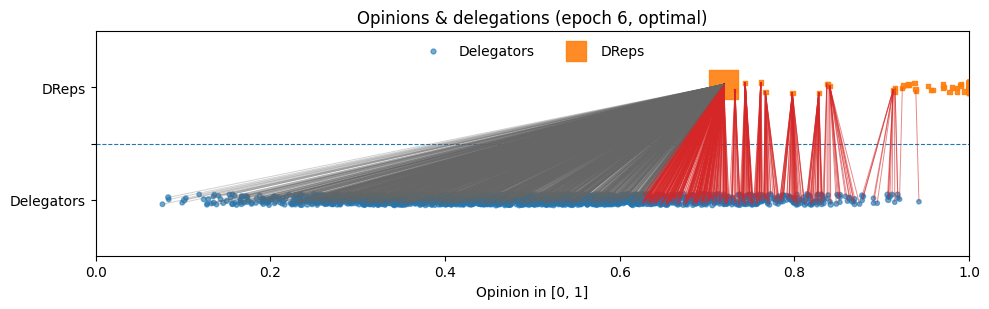

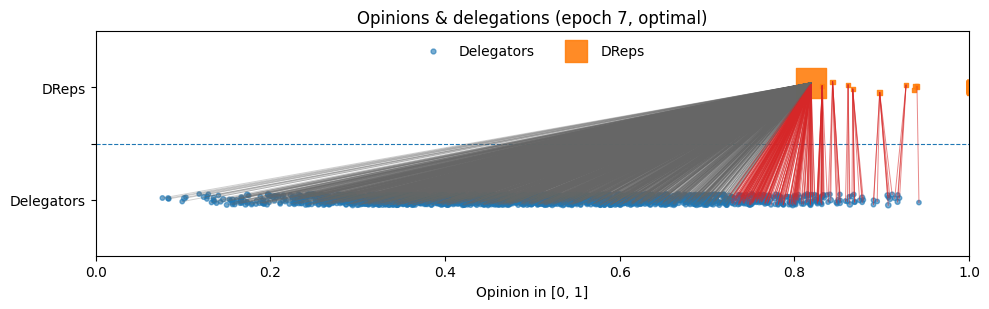

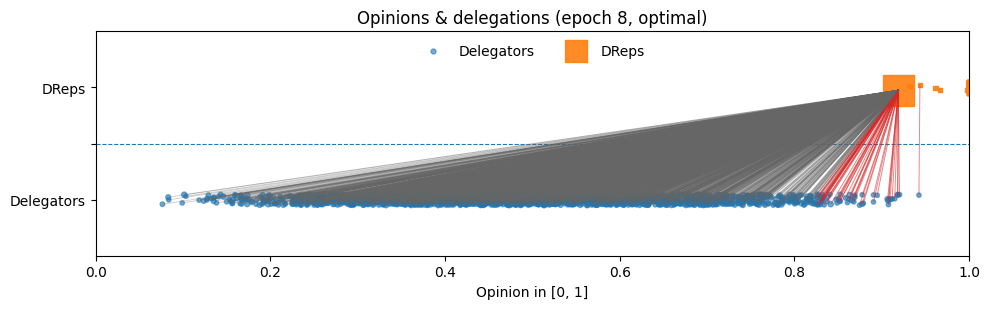

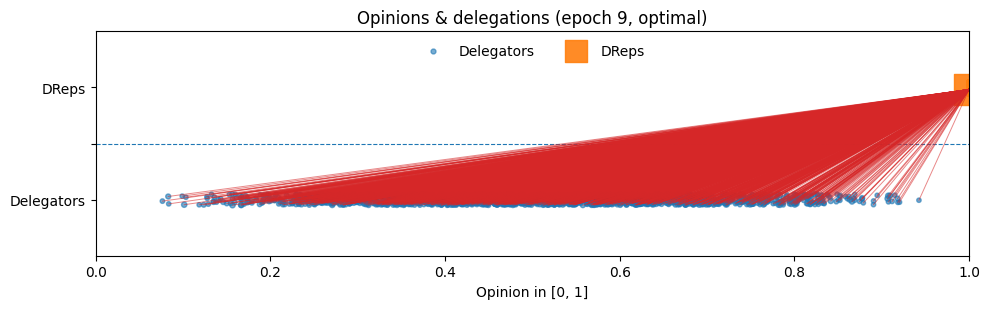

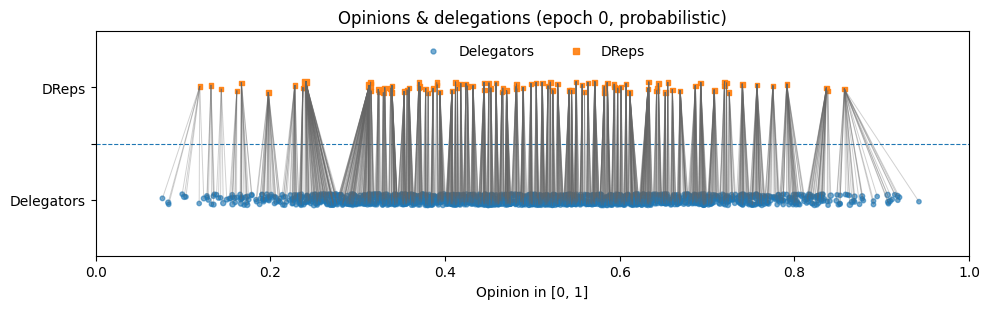

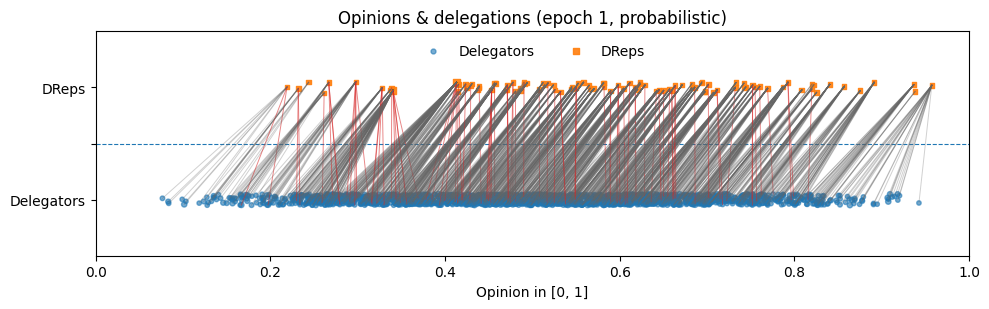

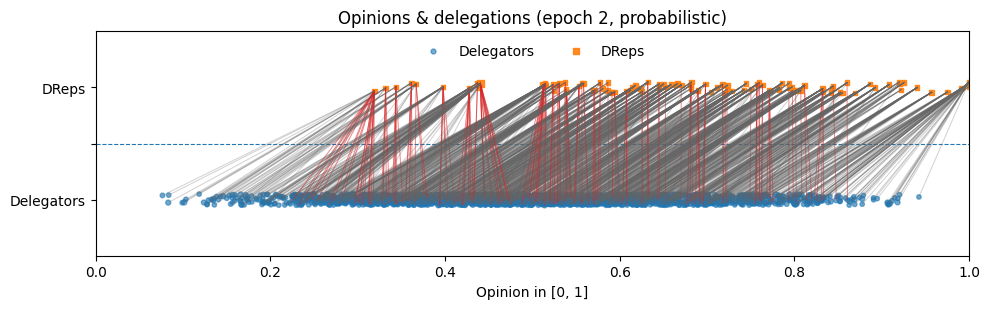

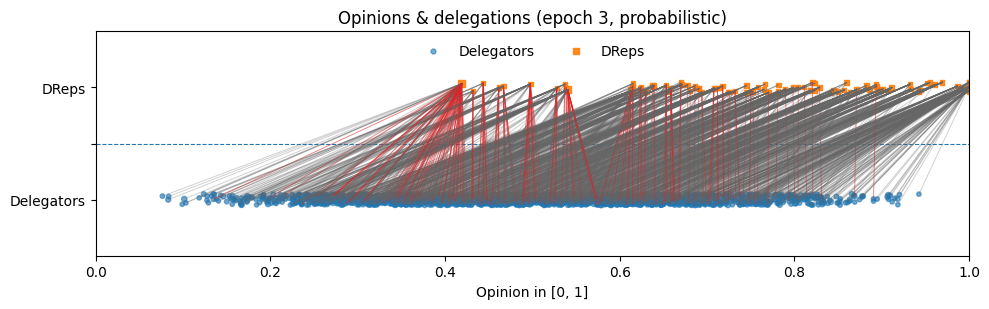

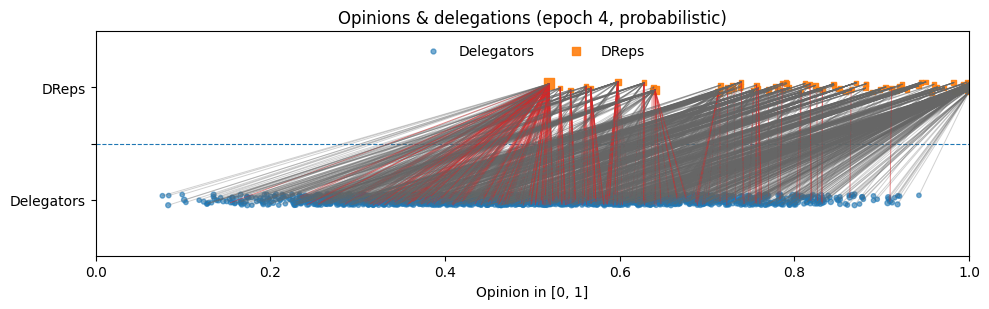

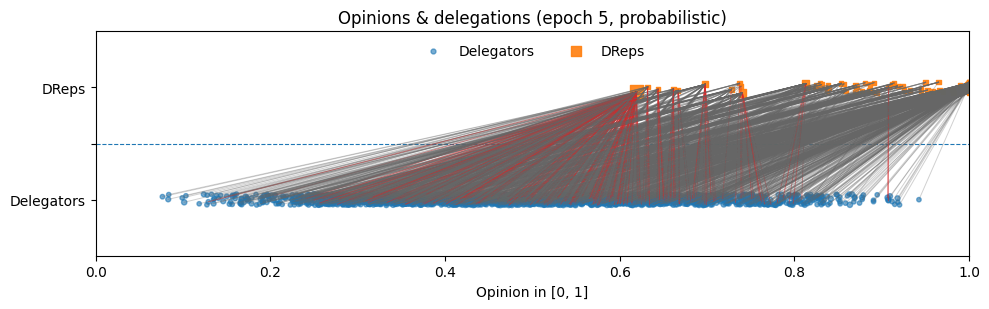

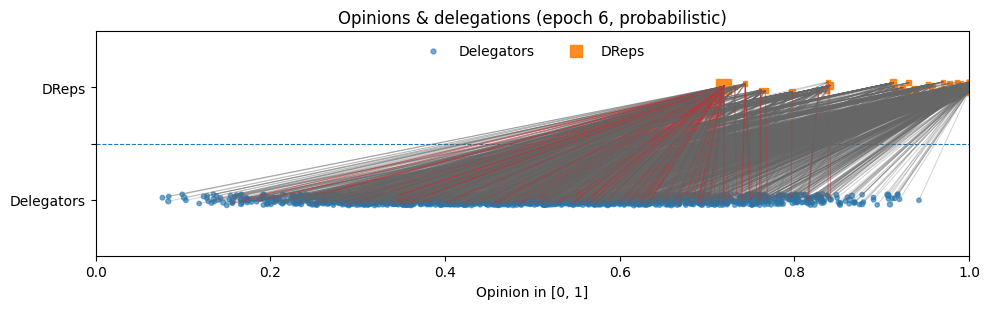

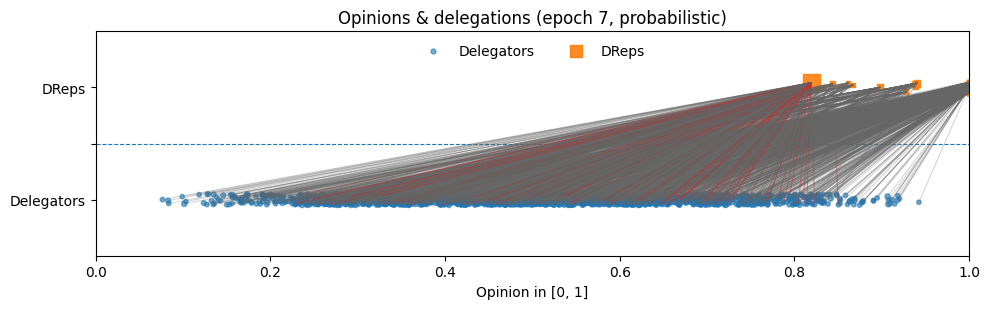

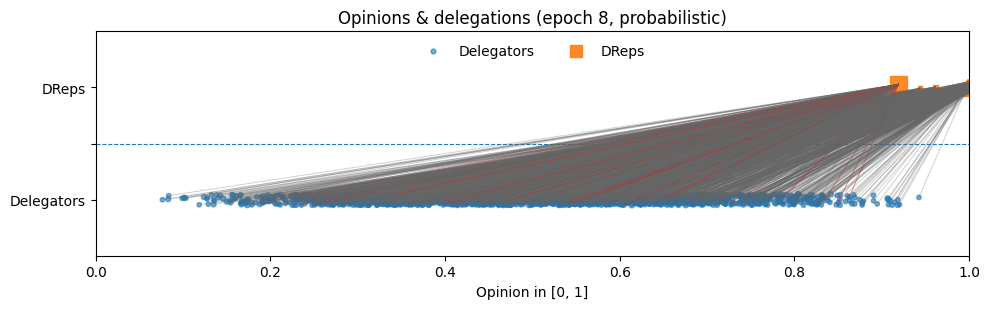

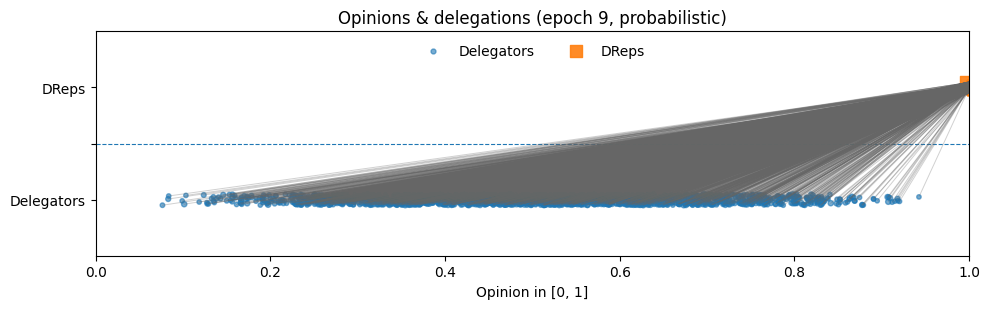

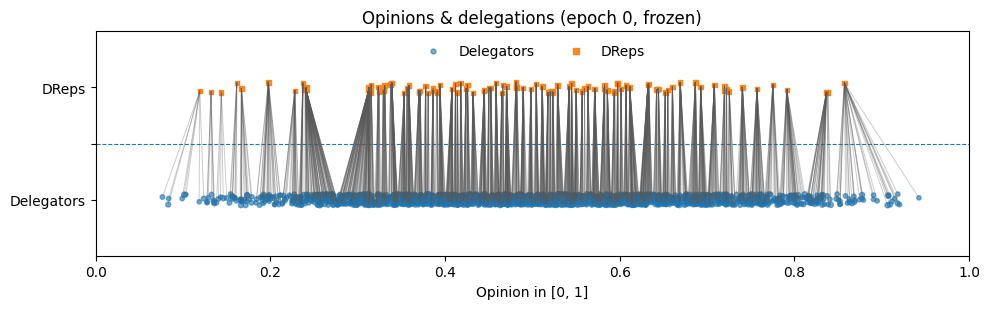

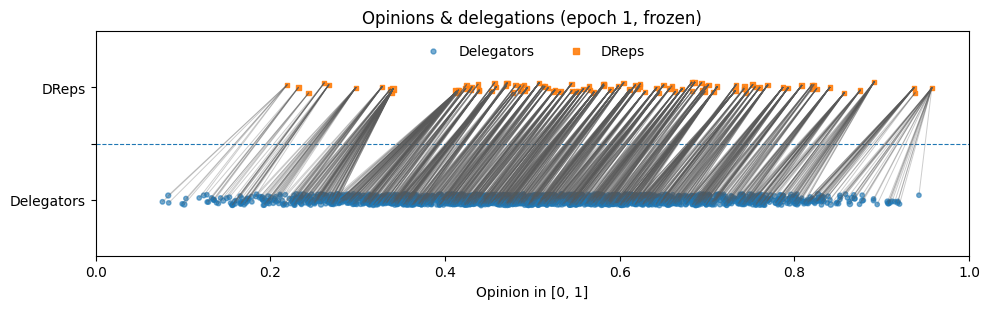

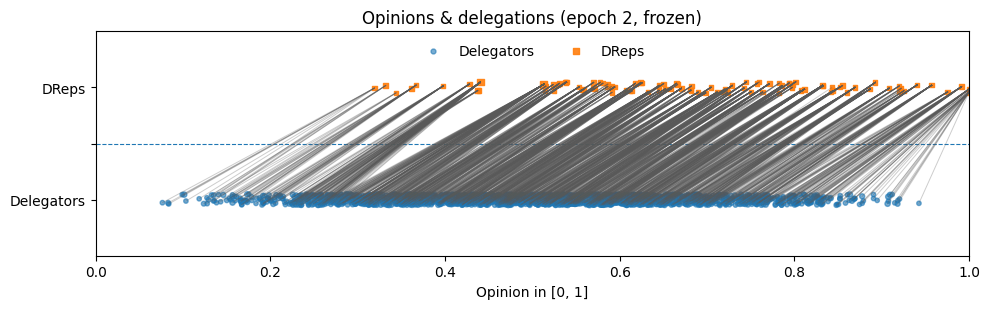

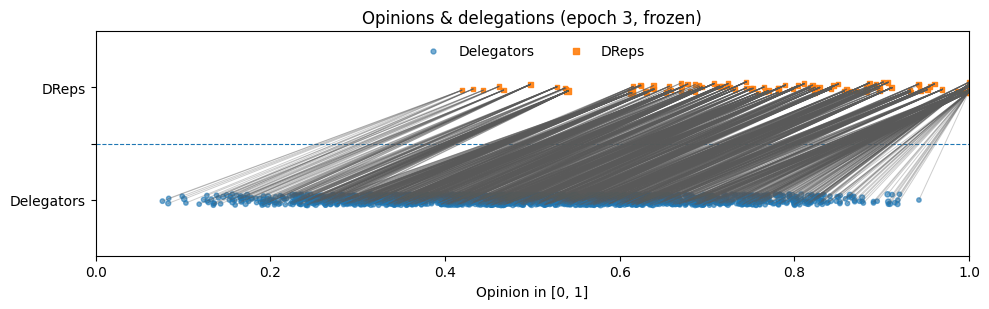

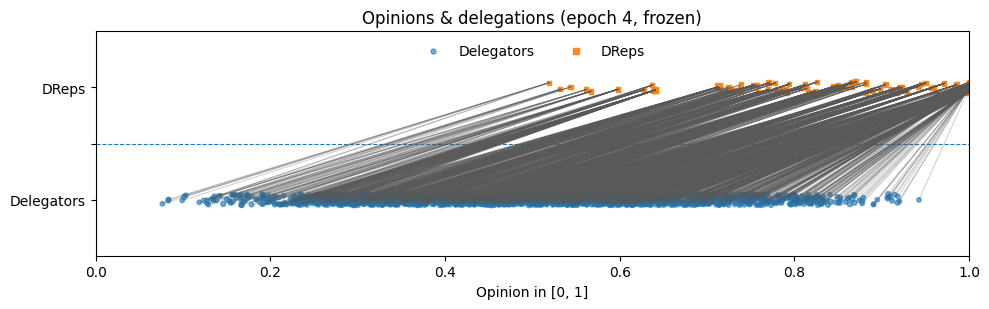

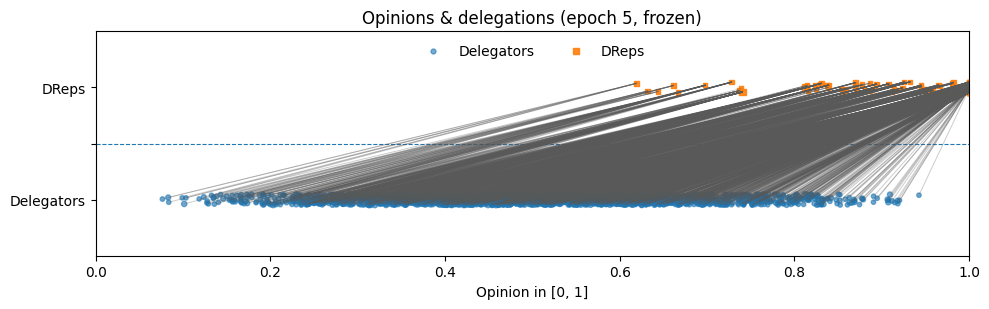

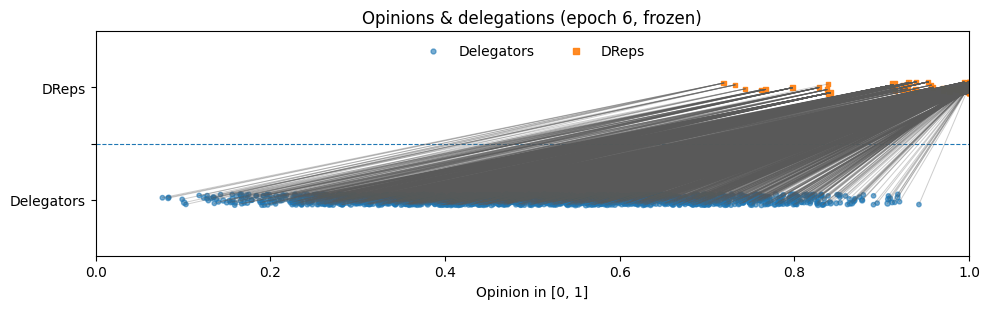

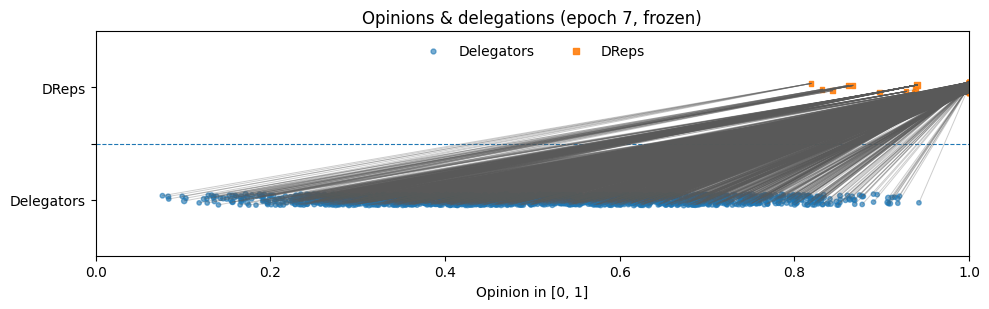

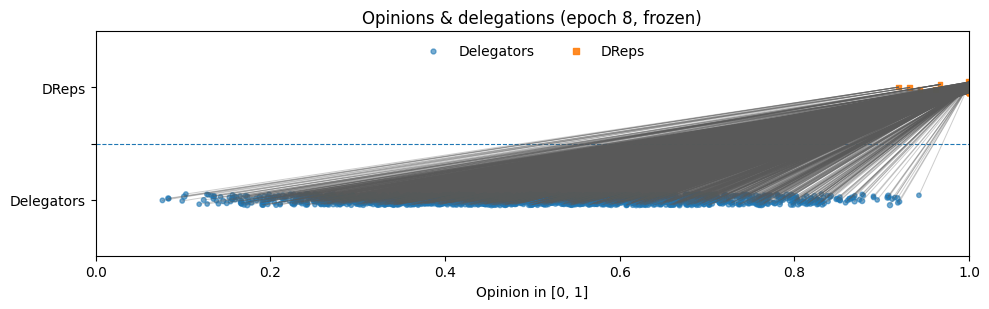

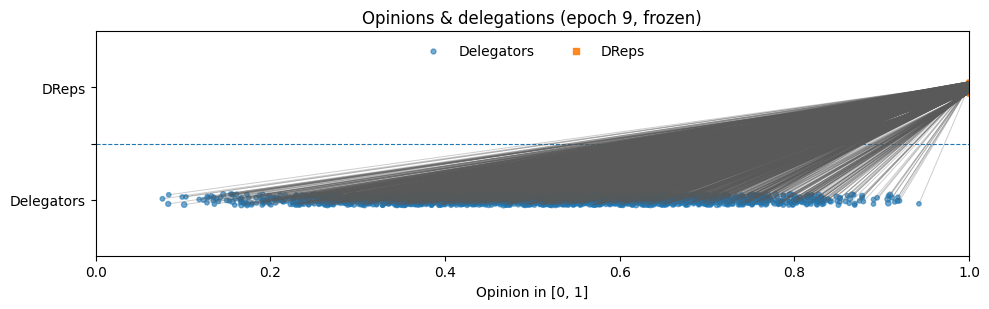

In [65]:

def load_source_frames(source: str):
    if source == "optimal":
        base = Path("csv_out_optimal")
        d_path = base / "delegators_state_with_delegations.csv"
        r_path = base / "dreps_state_with_wprime.csv"
    elif source == "probabilistic":
        base = Path("csv_out_probabilistic")
        d_path = base / "delegations_probabilistic.csv"
        r_path = base / "dreps_wprime_probabilistic.csv"
    elif source == "frozen":
        base = Path("csv_out_frozen")
        d_path = base / "delegators_state_frozen.csv"
        r_path = base / "dreps_state_with_wprime_frozen.csv"
    else:
        raise ValueError("unknown source")

    if not d_path.exists() or not r_path.exists():
        return None, None, None

    ddf = pd.read_csv(d_path)
    rdf = pd.read_csv(r_path)
    eps = sorted(set(ddf['epoch']).intersection(set(rdf['epoch'])))
    return ddf, rdf, eps
ALL_SOURCES = ["optimal", "probabilistic", "frozen"]
for src in ALL_SOURCES:
    ddf, rdf, eps = load_source_frames(src)
    if ddf is None:
        print(f"[skip] Source '{src}' missing expected CSVs.")
        continue

    for e in eps:
        fig, ax = plot_epoch_from_csv_unified(
            int(e), ddf, rdf, source=src,
            use_stake_size=USE_STAKE_SIZE, size_scale_deleg=SIZE_SCALE_DELEG, size_scale_dreps=SIZE_SCALE_DREPS,
            jitter=JITTER, draw_edges=DRAW_EDGES, edge_alpha=EDGE_ALPHA, edge_lw=EDGE_LW,
            edge_samples=EDGE_SAMPLES, color_switched=COLOR_SWITCHED
        )
        # fig.savefig(out_dir / f"epoch_{int(e):04d}.png", dpi=160, bbox_inches="tight")

        plt.show()